In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("C:/Users/kusum/python_and_data_analyst_assignment_and_projects/EDA/Assignment IPL_DATASET.csv")



In [5]:
print(df.head())
print(df.shape)



   Jersey No          Player  Matches  Inns  Not Out  Runs Highest Score  \
0          1        KL Rahul       14    14        2   670          132*   
1          2  Shikhar Dhawan       17    17        3   618          106*   
2          3    David Warner       16    16        2   548           85*   
3          4    Shreyas Iyer       17    17        2   519           88*   
4          5    Ishan Kishan       14    13        4   516            99   

     Avg  Balls faced  Strike rate  100  50  4s  6s  
0  55.83          518       129.34    1   5  58  23  
1  44.14          427       144.73    2   4  67  12  
2  39.14          407       134.64    0   4  52  14  
3  34.60          421       123.27    0   3  40  16  
4  57.33          354       145.76    0   4  36  30  
(133, 14)


In [6]:
df.tail

<bound method NDFrame.tail of      Jersey No             Player  Matches  Inns  Not Out  Runs Highest Score  \
0            1           KL Rahul       14    14        2   670          132*   
1            2     Shikhar Dhawan       17    17        3   618          106*   
2            3       David Warner       16    16        2   548           85*   
3            4       Shreyas Iyer       17    17        2   519           88*   
4            5       Ishan Kishan       14    13        4   516            99   
..         ...                ...      ...   ...      ...   ...           ...   
128        129      Khaleel Ahmed        7     1        0     0            0*   
129        130     Arshdeep Singh        8     1        0     0            0*   
130        131        Daniel Sams        3     1        0     0            0*   
131        132  Shreevats Goswami        2     2        0     0            0*   
132        133        Trent Boult       15     1        0     0            0*  

In [ ]:
Q1. What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.

In [9]:
#A- 
matches_per_player = df.groupby(['Player', 'Matches']).size().reset_index(name='Matches_Played')

max_matches = matches_per_player.loc[matches_per_player['Matches_Played'].idxmax()]

print("Player with maximum matches in a season:")
print(max_matches)


Player with maximum matches in a season:
Player            ABD Villiers
Matches                     15
Matches_Played               1
Name: 0, dtype: object


In [ ]:
Q2. Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [13]:
#A-
df['50_num'] = pd.to_numeric(df['50'], errors='coerce')
df['Avg_num'] = pd.to_numeric(df['Avg'], errors='coerce')
filtered = df[df['50_num'] >= 2].copy()
top2 = filtered.sort_values(by='Avg_num', ascending=False)[['Player', 'Avg', '50']].head(2)
top2




,Player,Avg,50
36,Wriddhiman Saha,71.33,2
4,Ishan Kishan,57.33,4


In [14]:
#Q3. Create 2 new columns based on Player name. First column will have first name and second column will have last name. Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [16]:
#A-
df[['First_Name', 'Last_Name']] = df['Player'].str.split(n=1, expand=True)
print(df[['Player', 'First_Name', 'Last_Name']])


                Player First_Name Last_Name
0             KL Rahul         KL     Rahul
1       Shikhar Dhawan    Shikhar    Dhawan
2         David Warner      David    Warner
3         Shreyas Iyer    Shreyas      Iyer
4         Ishan Kishan      Ishan    Kishan
..                 ...        ...       ...
128      Khaleel Ahmed    Khaleel     Ahmed
129     Arshdeep Singh   Arshdeep     Singh
130        Daniel Sams     Daniel      Sams
131  Shreevats Goswami  Shreevats   Goswami
132        Trent Boult      Trent     Boult

[133 rows x 3 columns]


In [17]:
#Q4. Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [21]:
#A-
df['Cleaned_Highest_score'] = df['Highest Score'].astype(str).str.replace('*', '', regex=False).astype(int)
print(df[['Player', 'Highest Score', 'Cleaned_Highest_score']].head(10))

             Player Highest Score  Cleaned_Highest_score
0          KL Rahul          132*                    132
1    Shikhar Dhawan          106*                    106
2      David Warner           85*                     85
3      Shreyas Iyer           88*                     88
4      Ishan Kishan            99                     99
5      Quinton Kock           78*                     78
6  Suryakumar Yadav           79*                     79
7  Devdutt Padikkal            74                     74
8       Virat Kohli           90*                     90
9      ABD Villiers           73*                     73


In [ ]:
Q5. Print the total number of centuries scored in the entire season.

In [23]:
#A-
total_centuries = df['100'].sum()
print("Total number of centuries scored in the entire season:", int(total_centuries))

Total number of centuries scored in the entire season: 5


In [24]:
#Q6. Print all the player names whose strike rate is less than the average strike rate of all players in entire season. Print the player name, his strike rate and average strike rate.

In [28]:
#A-
average_sr = df['Strike rate'].mean()
below_avg_players = df[df['Strike rate'] < average_sr]
below_avg_players = below_avg_players.copy()
below_avg_players['Average_Strike rate'] = average_sr
print(below_avg_players[['Player', 'Strike rate', 'Average_Strike rate']])


                  Player  Strike rate  Average_Strike rate
51        Ajinkya Rahane       105.60           107.364737
55         Glenn Maxwell       101.88           107.364737
58         Vijay Shankar       101.04           107.364737
61         Josh Philippe       101.29           107.364737
62       Gurkeerat Singh        88.75           107.364737
65          Kedar Jadhav        93.93           107.364737
70      Yashasvi Jaiswal        90.90           107.364737
71         Shreyas Gopal        94.87           107.364737
77          Murali Vijay        74.41           107.364737
79          Chris Jordan        93.54           107.364737
80         Navdeep Saini       100.00           107.364737
82     Kamlesh Nagarkoti        70.96           107.364737
84         Harshal Patel        87.50           107.364737
85         Jimmy Neesham       105.55           107.364737
86            Tom Banton        90.00           107.364737
89     Prabhsimran Singh       100.00           107.3647

In [ ]:
Q7. Please check the correlation between the features and create a heat map.

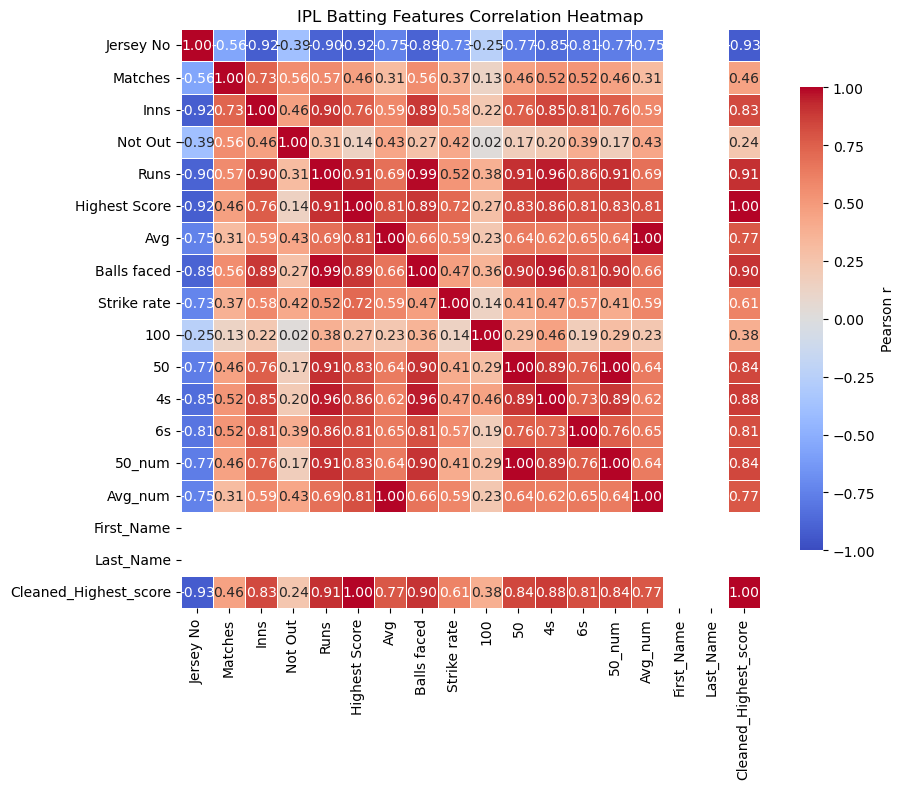

In [41]:
#A- 
for c in df.columns:
    if c not in ["Player"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
corr = df.select_dtypes(include=[np.number]).corr(method="pearson")
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"})
plt.title("IPL Batting Features Correlation Heatmap")
plt.tight_layout()
plt.show()


In [ ]:

Q8. Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.


In [45]:
#A-
mask = (df["Avg"] > 50) & (df["Strike rate"] > 120)
result = df.loc[mask, ["Player", "Avg", "Strike rate"]].sort_values(by=["Avg", "Strike rate"], ascending=False)
print(result.to_string(index=False))

         Player    Avg  Strike rate
   Deepak Hooda 101.00       142.25
     Tom Curran  83.00       133.87
Wriddhiman Saha  71.33       139.86
   Ishan Kishan  57.33       145.76
       KL Rahul  55.83       129.34
 Kieron Pollard  53.60       191.42
Ruturaj Gaikwad  51.00       120.71


In [46]:
#Q9. Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [48]:
mask = (df["Avg"] > 40) & (df["Balls faced"] > 100)
result = (df.loc[mask, ["Player", "Avg", "Balls faced"]].sort_values(by=["Avg", "Balls faced"], ascending=False))

print(result.to_string(index=False))

         Player   Avg  Balls faced
Wriddhiman Saha 71.33          153
   Ishan Kishan 57.33          354
       KL Rahul 55.83          518
 Kieron Pollard 53.60          140
Ruturaj Gaikwad 51.00          169
Ravindra Jadeja 46.40          135
   ABD Villiers 45.40          286
Kane Williamson 45.28          237
 Shikhar Dhawan 44.14          427
  Rahul Tewatia 42.50          183
    Virat Kohli 42.36          384
    Eoin Morgan 41.80          302
    Chris Gayle 41.14          210
  Faf Duplessis 40.81          319
     Ben Stokes 40.71          200


In [ ]:
Q10. Players who scored atleast one century in this season. Create visualization.

Players with at least one century:
        Player  100
Shikhar Dhawan    2
    Ben Stokes    1
      KL Rahul    1
Mayank Agarwal    1


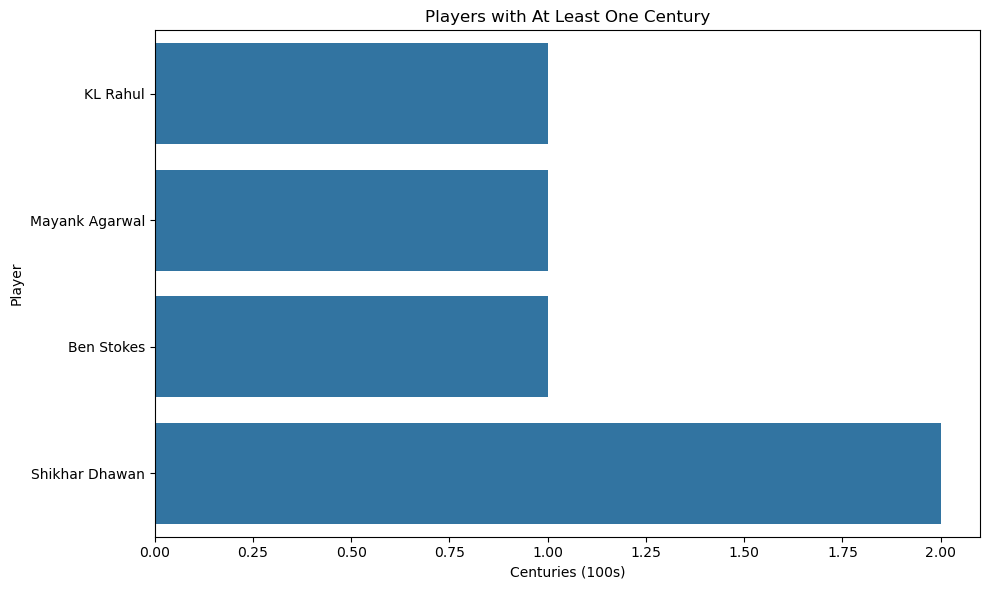

In [49]:
#A-
centurions = df[df["100"] >= 1].copy()
print("Players with at least one century:")
print(centurions.loc[:, ["Player", "100"]].sort_values(["100", "Player"], ascending=[False, True]).to_string(index=False))

plt.figure(figsize=(10, 6))
order = centurions.sort_values("100", ascending=True)
sns.barplot(data=order, x="100", y="Player", color="#1f77b4")
plt.xlabel("Centuries (100s)")
plt.ylabel("Player")
plt.title("Players with At Least One Century")
plt.tight_layout()
plt.show()

In [ ]:
Q11. Players who scored atleast 4 half centuries in this season.



In [51]:
#A-
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df["50"] = pd.to_numeric(df["50"], errors="coerce")
result = (df.loc[df["50"] >= 4, ["Player", "50"]].sort_values(by=["50", "Player"], ascending=[False, True]))
print("Players with at least four half-centuries:")
print(result.to_string(index=False))

Players with at least four half-centuries:
          Player  50
    ABD Villiers   5
Devdutt Padikkal   5
        KL Rahul   5
    David Warner   4
   Faf Duplessis   4
    Ishan Kishan   4
    Quinton Kock   4
  Shikhar Dhawan   4
Suryakumar Yadav   4


In [ ]:
Q12. Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [54]:
#A-
df["4s"] = pd.to_numeric(df["4s"], errors="coerce")
df["6s"] = pd.to_numeric(df["6s"], errors="coerce")
res = (df.loc[(df["4s"] > 45) & (df["6s"] > 10), ["Player", "4s", "6s"]].sort_values(by=["4s","6s","Player"], ascending=[False, False, True]))

print("Players with >45 fours and >10 sixes:")
print(res.to_string(index=False))


Players with >45 fours and >10 sixes:
          Player  4s  6s
  Shikhar Dhawan  67  12
Suryakumar Yadav  61  11
        KL Rahul  58  23
    David Warner  52  14
    Quinton Kock  46  22


In [ ]:
Q13. Plot a histogram of number of matches played in a season by players

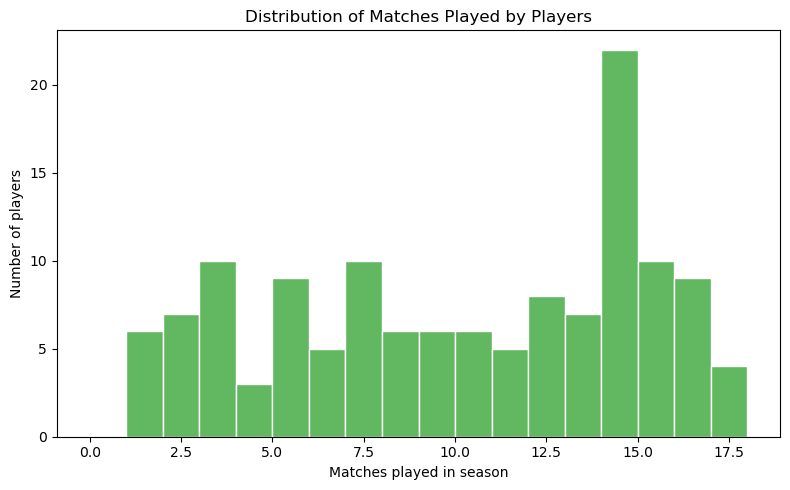

In [56]:
#A-
plt.figure(figsize=(8, 5))
sns.histplot(df["Matches"].dropna(), bins=range(0, 19, 1), kde=False, color="#2ca02c", edgecolor="white")
plt.xlabel("Matches played in season")
plt.ylabel("Number of players")
plt.title("Distribution of Matches Played by Players")
plt.tight_layout()
plt.show()

In [ ]:
Q14. Plot the histogram of balls faced by players.

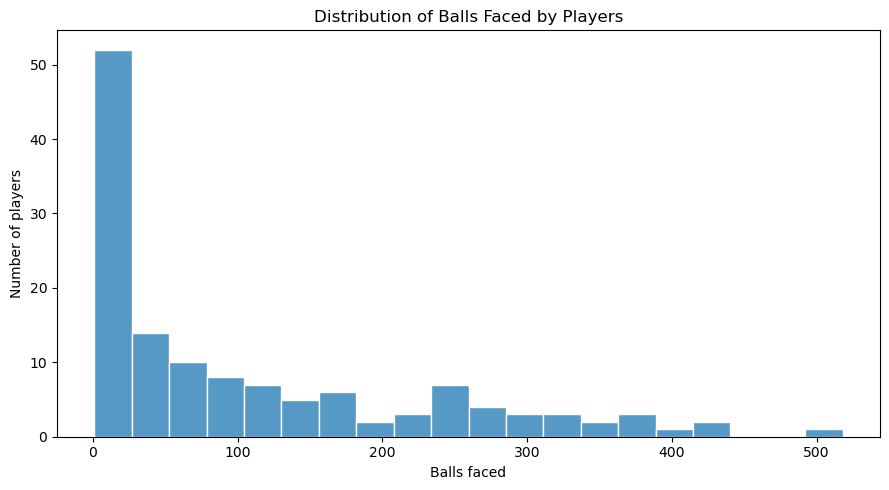

In [57]:
#A-
plt.figure(figsize=(9, 5))
sns.histplot(df["Balls_faced"].dropna(), bins=20, kde=False, color="#1f77b4", edgecolor="white")
plt.xlabel("Balls faced")
plt.ylabel("Number of players")
plt.title("Distribution of Balls Faced by Players")
plt.tight_layout()
plt.show()

In [ ]:
Q15. Top 10 players with most runs in a season.

In [58]:
#A-
top10 = (df.sort_values("Runs", ascending=False).loc[:, ["Player", "Runs", "Matches", "Inns", "Avg", "Strike_rate"]].head(10))

print("Top 10 players with most runs in the season:")
print(top10.to_string(index=False))

Top 10 players with most runs in the season:
          Player  Runs  Matches  Inns   Avg  Strike_rate
        KL Rahul   670       14    14 55.83       129.34
  Shikhar Dhawan   618       17    17 44.14       144.73
    David Warner   548       16    16 39.14       134.64
    Shreyas Iyer   519       17    17 34.60       123.27
    Ishan Kishan   516       14    13 57.33       145.76
    Quinton Kock   503       16    16 35.92       140.50
Suryakumar Yadav   480       16    15 40.00       145.01
Devdutt Padikkal   473       15    15 31.53       124.80
     Virat Kohli   466       15    15 42.36       121.35
    ABD Villiers   454       15    14 45.40       158.74


In [ ]:
Q16. Print the players who played the match but didn't get the batting.

In [59]:
#A-
mask = (df["Matches"] > 0) & (df["Inns"] == 0)
result = df.loc[mask, ["Player", "Matches", "Inns"]]
print("Players who played but didn't bat:")
print(result.to_string(index=False))

Players who played but didn't bat:
Empty DataFrame
Columns: [Player, Matches, Inns]
Index: []


In [60]:
#Q17. Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [61]:
#A-
df["Boundary_Runs"] = 4*df["4s"] + 6*df["6s"]
df["Boundary_%"] = 100 * df["Boundary_Runs"] / df["Runs"].replace(0, np.nan)
top5 = (df.dropna(subset=["Boundary_%"]).sort_values("Boundary_%", ascending=False).loc[:, ["Player", "Runs", "4s", "6s", "Boundary_Runs", "Boundary_%"]].head(5))

print("Top 5 players by % of runs from 4s and 6s:")
print(top5.to_string(index=False, formatters={"Boundary_%": "{:.2f}".format}))

Top 5 players by % of runs from 4s and 6s:
       Player  Runs  4s  6s  Boundary_Runs Boundary_%
   Andrew Tye     6   0   1              6     100.00
Andre Russell   117   9   9             90      76.92
 Chris Morris    34   2   3             26      76.47
Hardik Pandya   281  14  25            206      73.31
 Sunil Narine   121  10   8             88      72.73


In [ ]:
Q18. Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [62]:
#A-
df["NotOut_%"] = 100.0 * df["Not_Out"] / df["Inns"].replace(0, np.nan)
top5 = (df.dropna(subset=["NotOut_%"]).sort_values("NotOut_%", ascending=False).loc[:, ["Player", "Inns", "Not_Out", "NotOut_%"]].head(5))

print("Top 5 players by Not Out percentage:")
print(top5.to_string(index=False, formatters={"NotOut_%": "{:.2f}".format}))

Top 5 players by Not Out percentage:
         Player  Inns  Not_Out NotOut_%
Dhawal Kulkarni     1        1   100.00
   Rahul Chahar     1        1   100.00
Prasidh Krishna     2        2   100.00
Gurkeerat Singh     5        5   100.00
Lockie Ferguson     2        2   100.00


In [ ]:
Q19. Create visualization of top 10 players with highest number of sixes.

Top 10 players by number of sixes:
         Player  6s
   Ishan Kishan  30
   Sanju Samson  26
Nicholas Pooran  25
  Hardik Pandya  25
    Eoin Morgan  24
    Chris Gayle  23
   ABD Villiers  23
       KL Rahul  23
   Quinton Kock  22
 Kieron Pollard  22


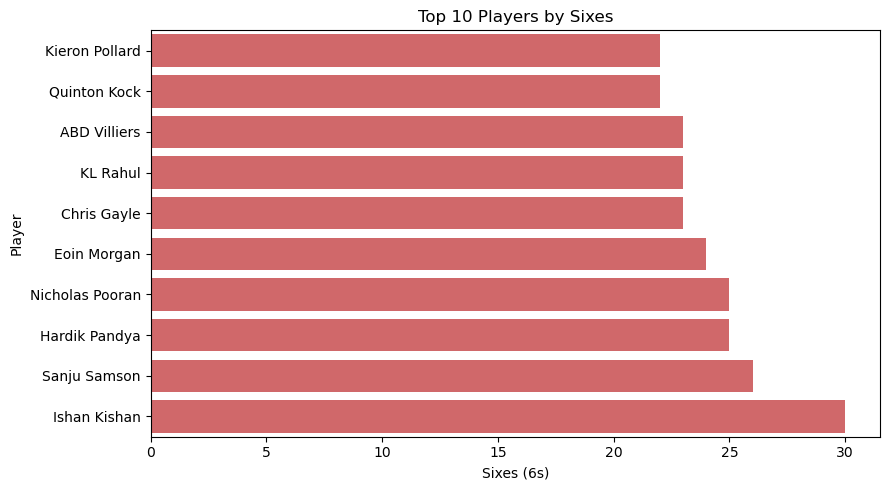

In [63]:
#A-
top10_6s = (df.sort_values("6s", ascending=False).loc[:, ["Player", "6s"]].head(10))

print("Top 10 players by number of sixes:")
print(top10_6s.to_string(index=False))

plt.figure(figsize=(9, 5))
sns.barplot(data=top10_6s.sort_values("6s", ascending=True), x="6s", y="Player", color="#e15759")
plt.xlabel("Sixes (6s)")
plt.ylabel("Player")
plt.title("Top 10 Players by Sixes")
plt.tight_layout()
plt.show()

In [ ]:
Q20. Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.

Text(0.5, 1.0, 'Runs vs Balls Faced')

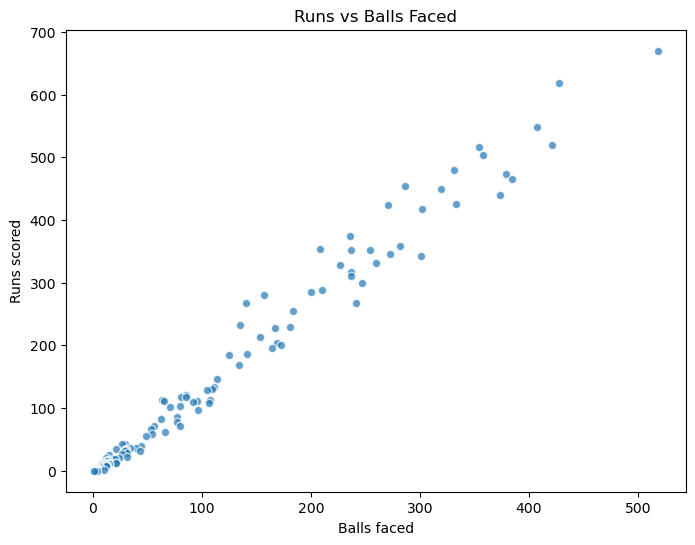

In [69]:
#A-
x = pd.to_numeric(df["Balls_faced"], errors="coerce")
y = pd.to_numeric(df["Runs"], errors="coerce")
mask = x.notna() & y.notna()
x = x[mask].to_numpy()
y = y[mask].to_numpy()
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, edgecolors="white")
plt.xlabel("Balls faced")
plt.ylabel("Runs scored")
plt.title("Runs vs Balls Faced")
